
TPS 
TPS0 isi: 33 / 429
TPS1 isi: 56 / 499
TPS2 isi: 266 / 416

kendaraan 
G0 | waktu: 222 | jarak: 56 | sisa muatan: 0 kg | zona: TPS0
G1 | waktu: 408 | jarak: 108 | sisa muatan: 0 kg | zona: TPS1
G2 | waktu: 458 | jarak: 108 | sisa muatan: 0 kg | zona: TPS2
T0 | waktu: 8.0 | jarak: 12 | sisa muatan: 0 kg | zona: TPS0
T1 | waktu: 24.4 | jarak: 36 | sisa muatan: 0 kg | zona: TPS1
T2 | waktu: 97.2 | jarak: 144 | sisa muatan: 0 kg | zona: TPS2
G3 | waktu: 538 | jarak: 130 | sisa muatan: 0 kg | zona: TPS2
G4 | waktu: 538 | jarak: 132 | sisa muatan: 0 kg | zona: TPS2
T3 | waktu: 7.6 | jarak: 12 | sisa muatan: 0 kg | zona: TPS0

total jarak semua kendaraan: 738

Sisa sampah rumah
0

Zona TPS2:

Zona TPS1:

Zona TPS0:

log aktivitas kendaraan

 G0
06.09 - G0 ambil 5kg dari H32 | jarak: 3
06.28 - G0 buang 5kg ke TPS0
06.34 - G0 ambil 3kg dari H13 | jarak: 2
06.46 - G0 buang 3kg ke TPS0
06.55 - G0 ambil 4kg dari H50 | jarak: 3
07.12 - G0 buang 4kg ke TPS0
07.15 - G0 ambil 2kg dari H55 | jarak

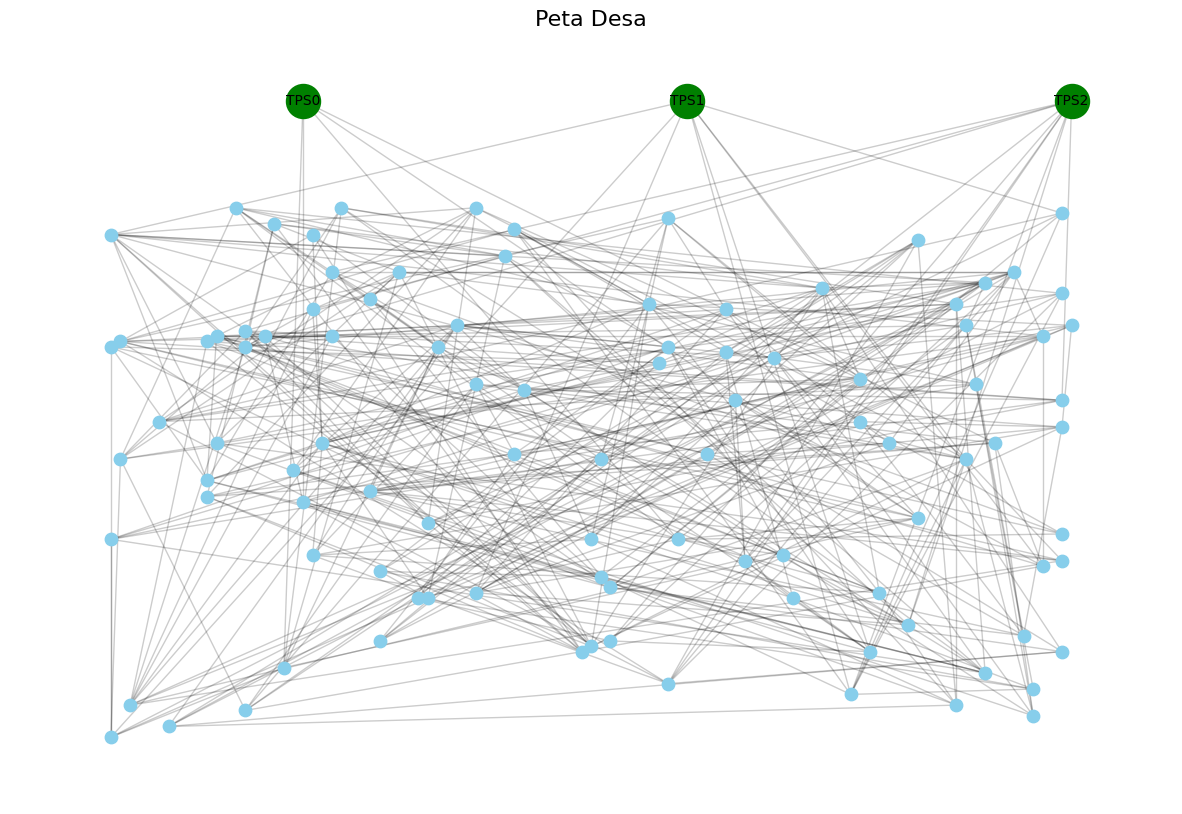

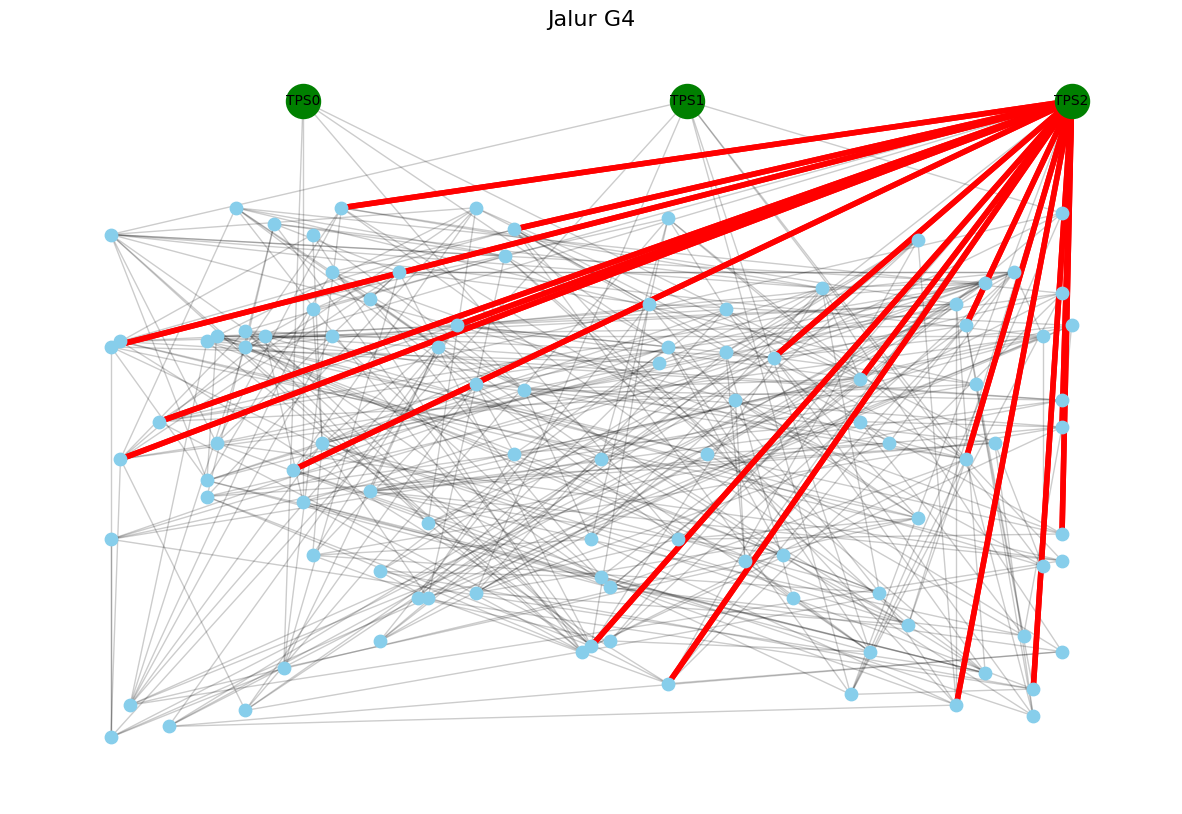

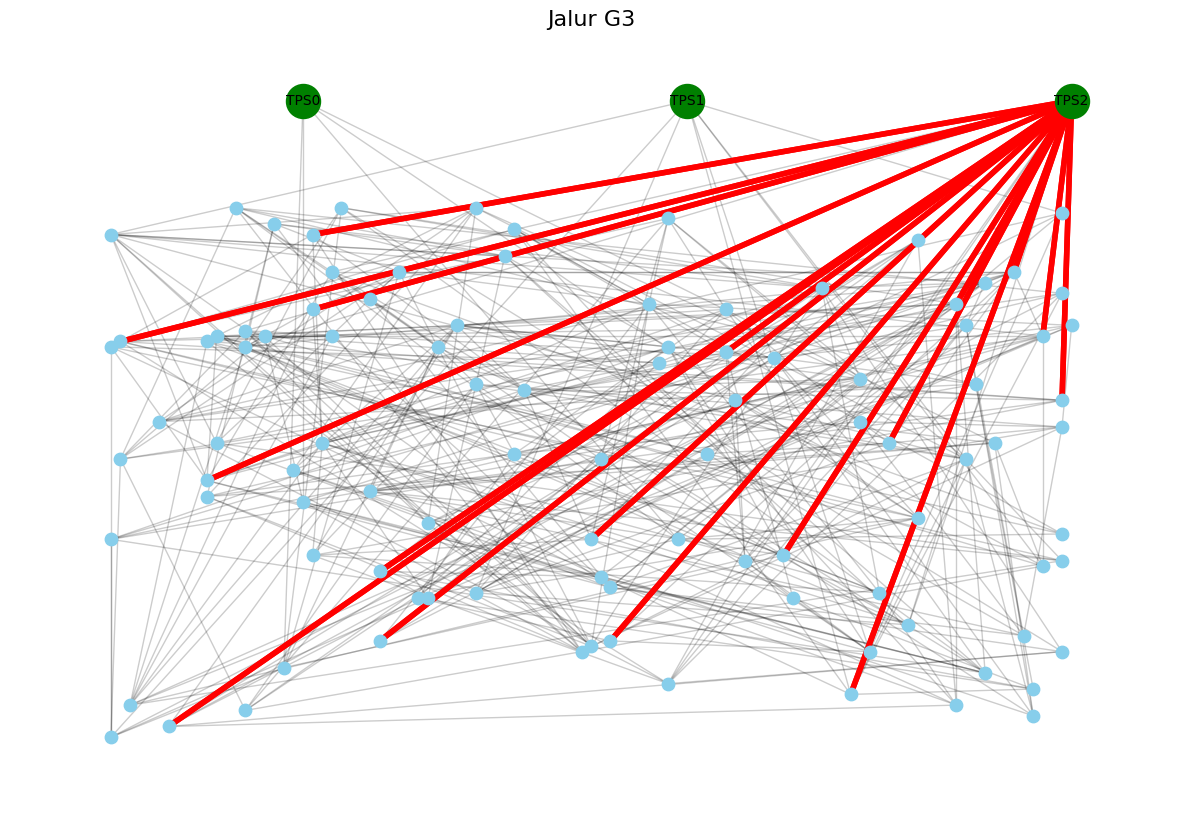

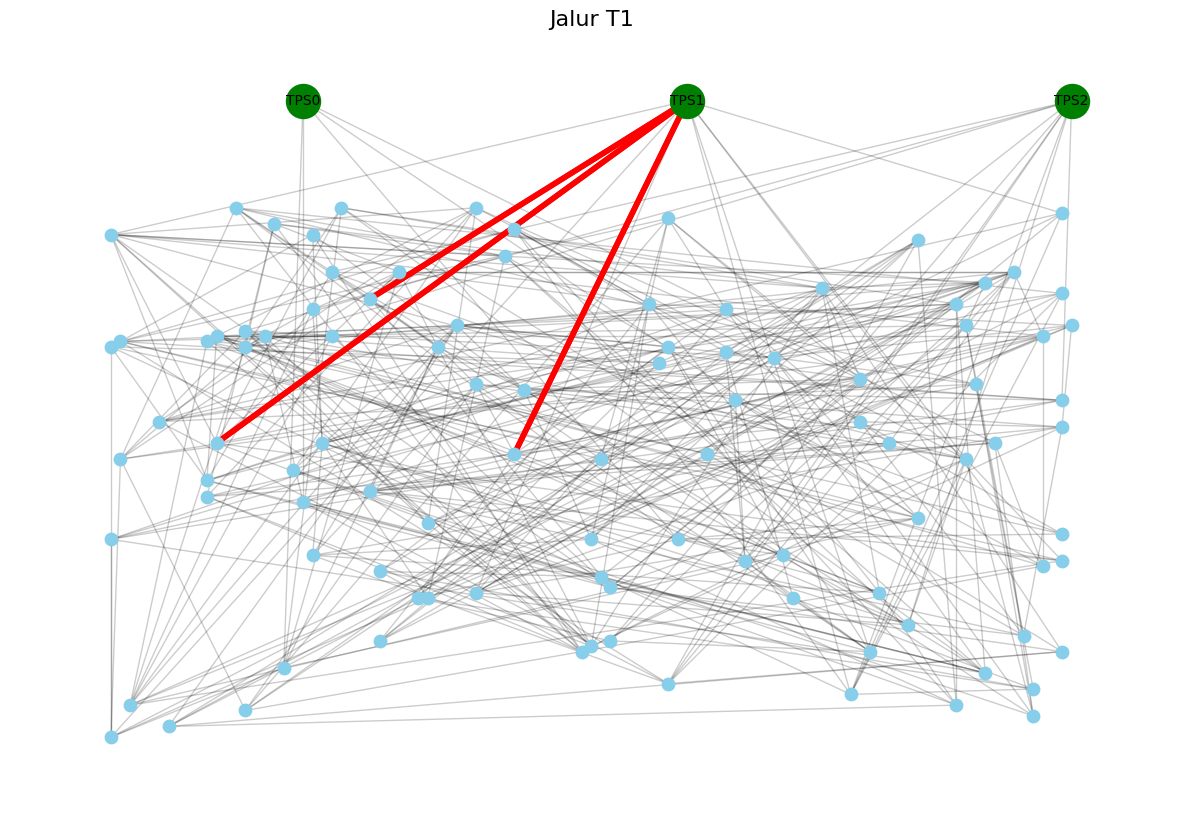

In [11]:
import random
import heapq
import networkx as nx
import matplotlib.pyplot as plt


jumlah_rumah = 100
jumlah_tps = 3
total_gerobak = random.randint(5, 7)
total_truk = random.randint(2, 4)
kapasitas_gerobak = 15
kapasitas_truk = 200
gerobak_mulai = 6 * 60
gerobak_selesai = 15 * 60
truk_mulai = 8 * 60
truk_selesai = 17 * 60

class House:
    def __init__(self, id):
        self.id = f"H{id}"
        self.waste = random.randint(0, 7) # jumlah sampah di satu rumah, dalam kg
class TPS:
    def __init__(self, id):
        self.id = id
        self.capacity = random.randint(400, 500) # kapasitas TPS dalam kg
        self.current = 0 # jumlah sampah yang sudah ada di TPS

# untuk assignment rumah ke truk/gerobak
class Vehicle:
    def __init__(self, name, vtype, home_tps):
        self.name = name
        self.vtype = vtype
        self.home_tps = home_tps # zona utamanya
        self.position = home_tps
        self.route = [home_tps]
        self.load = 0 # isi muatan saat ini
        self.cargo_detail = {}
        self.distance = 0
        self.time_used = 0
        self.log = []
        self.start_time = gerobak_mulai if vtype == "gerobak" else truk_mulai
    def free_capacity(self): # sisa kapasitas yang bisa diisi
        if self.vtype == "gerobak":
            return kapasitas_gerobak - self.load
        return kapasitas_truk - self.load

# buat graph
graph = {}
all_nodes = []
houses = [House(i) for i in range(jumlah_rumah)]
tps_nodes = [TPS(f"TPS{i}") for i in range(jumlah_tps)]
all_nodes.extend(houses)
all_nodes.extend(tps_nodes)
for node in all_nodes: # inisialisasi graph
    graph[node.id] = []
for node in all_nodes: # untuk setiap node, buat 2-5 tetangga acak dengan jarak 1-5
    neighbors = random.sample(
        [n for n in all_nodes if n.id != node.id],
        random.randint(2, 5)
    )
    for nb in neighbors: # untuk setiap tetangga, tambahkan ke graph dengan jarak acak
        d = random.randint(1, 5)
        graph[node.id].append((nb.id, d))
        graph[nb.id].append((node.id, d))

# POSISI NODE UNTUK VISUALISASI

positions = {}

# posisi rumah acak

for h in houses:

    positions[h.id] = (
        random.randint(0, 100),
        random.randint(0, 100)
    )

# posisi TPS di bagian atas peta

for i, tps in enumerate(tps_nodes):

    positions[tps.id] = (
        20 + i * 40,
        120
    )
# shortest path ucs
def shortest_path(start, goal):
    pq = [] # priority queue untuk UCS
    heapq.heappush(pq, (0, start))
    visited = set() # untuk menyimpan node yang sudah dikunjungi
    while pq:
        cost, node = heapq.heappop(pq) # ambil node dengan cost terendah
        if node == goal:
            return cost
        if node in visited:
            continue
        visited.add(node)
        for nxt, dist in graph[node]: # nxt adalah tetangga, dist adalah jarak ke tetangga
            if nxt not in visited:
                heapq.heappush(pq, ( cost + dist, str(nxt)))
    return 999999

house_zone = {} # untuk menyimpan zona rumah, yaitu TPS terdekatnya
house_tps_distance = {}
for h in houses:
    nearest = None
    best_dist = 999999
    for tps in tps_nodes:
        d = shortest_path(h.id, tps.id)
        if d < best_dist: # jika jarak ke TPS ini lebih dekat, update zona rumah
            best_dist = d
            nearest = tps.id
    house_zone[h.id] = nearest
    house_tps_distance[h.id] = best_dist

def nearest_available_tps(vehicle):
    best = None
    best_cost = 999999
    for tps in tps_nodes:
        if tps.current >= tps.capacity:
            continue
        c = shortest_path(vehicle.position, tps.id)
        if c < best_cost:
            best_cost = c
            best = tps # simpan objek TPS terbaik
    return best, best_cost

def best_house(vehicle):
    best = None
    best_score = -999
    best_dist = 0
    zone = vehicle.home_tps
    for h in houses:
        if h.waste <= 0:
            continue
        if house_zone[h.id] != zone:
            continue
        d = shortest_path(vehicle.position,h.id)
        tps_dist = shortest_path(h.id, zone)
        if vehicle.vtype == "gerobak":
            # prioritaskan dekat TPS
            if tps_dist > 5:
                continue
            score = (h.waste * 2 - d - tps_dist)
        else:
            # prioritaskan jauh TPS
            if tps_dist <= 5:
                continue
            score = (h.waste * 2 + tps_dist - d)
        if score > best_score:
            best_score = score
            best = h
            best_dist = d
    return best, best_dist

def max_operating_time(vehicle):
    if vehicle.vtype == "gerobak":
        return gerobak_selesai - gerobak_mulai
    return truk_selesai - truk_mulai
def can_move(vehicle, dist):
    if vehicle.vtype == "gerobak":
        t = dist * 3
    else:
        t = dist * (3 / 5)
    return (
        vehicle.time_used + t
        <= max_operating_time(vehicle)
    )
def can_load(vehicle, kg):
    if vehicle.vtype == "gerobak":
        t = kg * 2
    else:
        t = (kg / 10) * 2
    return (
        vehicle.time_used + t
        <= max_operating_time(vehicle)
    )
# TIME
def move(vehicle, dist):
    if not can_move(vehicle, dist):
        return False
    vehicle.distance += dist
    if vehicle.vtype == "gerobak":
        t = dist * 3
    else:
        t = dist * (3 / 5)
    vehicle.time_used += t
    return True

def load_house(vehicle, house, dist):
    cap = vehicle.free_capacity() # sisa kapasitas yang bisa diisi
    take = min(cap, house.waste) # min untuk memastikan tidak mengambil lebih dari yang bisa diangkut atau yang tersedia di rumah
    if take <= 0:
        return False
    if not can_load(vehicle, take):
        return False
    house.waste -= take
    vehicle.load += take
    vehicle.cargo_detail[h.id] = (vehicle.cargo_detail.get(h.id, 0) + take) # angka 0 untuk default jika rumah ini belum pernah diambil sebelumnya
    t = format_time(vehicle.start_time, vehicle.time_used)
    t = format_time(vehicle.start_time, vehicle.time_used)
    vehicle.log.append(f"{t} - {vehicle.name} ambil {take}kg dari {house.id} | jarak: {dist}")

def dump_to_tps(vehicle):
    if vehicle.load <= 0:
        return
    tps, dist = nearest_available_tps(vehicle)
    if tps is None:
        return
    if not move(vehicle, dist):
        return
    vehicle.position = tps.id
    vehicle.route.append(tps.id)
    can_dump = min(vehicle.load, tps.capacity - tps.current)
    remaining = can_dump
    dumped_from = [] # untuk mencatat dari rumah mana saja sampah yang dibuang ke TPS ini, dalam format "Hid:kg"
    for hid in list(vehicle.cargo_detail.keys()): # hid = id rumah yang diangkut
        if remaining <= 0:
            break
        amt = vehicle.cargo_detail[hid] # amt= jumlah yang diangkut dari rumah hid
        taken = min(amt, remaining) # jumlah yang diambil dari rumah ini untuk dibuang ke TPS
        dumped_from.append(f"{hid}:{taken}kg")
        vehicle.cargo_detail[hid] -= taken # update sisa yang diangkut dari rumah ini setelah dibuang ke TPS
        if vehicle.cargo_detail[hid] <= 0: # jika sudah habis, hapus dari cargo_detail
            del vehicle.cargo_detail[hid]
        remaining -= taken
    tps.current += can_dump
    vehicle.load -= can_dump
    if vehicle.vtype == "gerobak": # waktu yang dibutuhkan untuk membuang sampah ke TPS
        vehicle.time_used += can_dump * 2
    else:
        vehicle.time_used += (can_dump / 10) * 2
    detail = ", ".join(dumped_from)
    t = format_time(vehicle.start_time, vehicle.time_used)
    vehicle.log.append(f"{t} - {vehicle.name} buang {can_dump}kg ke {tps.id}")

def format_time(start_minutes, elapsed):
    total = start_minutes + int(elapsed)
    h = total // 60
    m = total % 60
    return f"{h:02d}.{m:02d}"

vehicles = []

used_gerobak = 0
used_truk = 0

# 1. JAMIN MINIMAL 1 GEROBAK PER TPS
for tps in tps_nodes:
    if used_gerobak < total_gerobak:
        vehicles.append(Vehicle(f"G{used_gerobak}", "gerobak", tps.id))
        used_gerobak += 1

# 2. JAMIN MINIMAL 1 TRUK PER TPS
for tps in tps_nodes:
    if used_truk < total_truk:
        vehicles.append(Vehicle(f"T{used_truk}", "truck", tps.id))
        used_truk += 1

# 3. SISA GEROBAK RANDOM
for i in range(used_gerobak, total_gerobak):
    tps = random.choice(tps_nodes)
    vehicles.append(Vehicle(f"G{i}", "gerobak", tps.id))

# 4. SISA TRUK RANDOM
for i in range(used_truk, total_truk):
    tps = random.choice(tps_nodes)
    vehicles.append(Vehicle(f"T{i}", "truck", tps.id))

def operate(vehicle):
    max_time = gerobak_selesai - gerobak_mulai \
        if vehicle.vtype == "gerobak" \
        else truk_selesai - truk_mulai
    while vehicle.time_used < max_time:
        if vehicle.load >= ( kapasitas_gerobak if vehicle.vtype == "gerobak" else kapasitas_truk):
            dump_to_tps(vehicle)
            continue
        house, dist = best_house(vehicle)
        if house is None:
            break
        move(vehicle, dist)
        vehicle.position = house.id
        vehicle.route.append(house.id)
        load_house(vehicle, house, dist)
        if vehicle.load > 0:
            dump_to_tps(vehicle)
        if not move(vehicle, dist):
            return
        vehicle.position = house.id
        if not load_house(vehicle, house, dist):
            return

def operate_one_step(vehicle):
    max_time = (
        gerobak_selesai - gerobak_mulai
        if vehicle.vtype == "gerobak"
        else truk_selesai - truk_mulai
    )

    if vehicle.time_used >= max_time:
        return

    house, dist = best_house(vehicle)
    if house is None:
        return

    # 1. MOVE SEKALI SAJA
    if not move(vehicle, dist):
        return
    vehicle.position = house.id
    vehicle.route.append(house.id)

    # 2. LOAD DI RUMAH (tanpa waktu)
    load_house(vehicle, house, dist)

    # 3. DUMP jika perlu
    if vehicle.load > 0:
        dump_to_tps(vehicle)

active = True
while active: 
    active = False
    for v in vehicles:
        before = v.time_used
        operate_one_step(v)
        if v.time_used > before:
            active = True
def draw_map(vehicle_name=None):

    G = nx.Graph()

    for node in graph:

        G.add_node(node)

    for node in graph:

        for nb, dist in graph[node]:

            G.add_edge(
                node,
                nb,
                weight=dist
            )

    plt.figure(figsize=(15,10))

    # semua jalan

    nx.draw_networkx_edges(
        G,
        positions,
        alpha=0.2
    )

    # rumah

    nx.draw_networkx_nodes(
        G,
        positions,
        nodelist=[h.id for h in houses],
        node_color="skyblue",
        node_size=80
    )

    # TPS

    nx.draw_networkx_nodes(
        G,
        positions,
        nodelist=[t.id for t in tps_nodes],
        node_color="green",
        node_size=600
    )

    nx.draw_networkx_labels(
        G,
        positions,
        labels={
            t.id:t.id
            for t in tps_nodes
        },
        font_size=10
    )

    # jalur kendaraan tertentu

    if vehicle_name:

        kendaraan = None

        for v in vehicles:

            if v.name == vehicle_name:

                kendaraan = v
                break

        if kendaraan and len(kendaraan.route) > 1:

            route_edges = []

            for i in range(
                len(kendaraan.route)-1
            ):

                route_edges.append(
                    (
                        kendaraan.route[i],
                        kendaraan.route[i+1]
                    )
                )

            nx.draw_networkx_edges(
                G,
                positions,
                edgelist=route_edges,
                edge_color="red",
                width=4
            )

            plt.title(
                f"Jalur {vehicle_name}",
                fontsize=16
            )

    else:

        plt.title(
            "Peta Desa",
            fontsize=16
        )

    plt.axis("off")

    plt.show()
  

# REPORT
print("\nTPS ")
for t in tps_nodes:
    print(t.id, "isi:", t.current, "/", t.capacity)

print("\nkendaraan ")
total_distance = 0
for v in vehicles:
    total_distance += v.distance
    print( v.name, "| waktu:", round(v.time_used, 2), "| jarak:", v.distance, "| sisa muatan:", v.load, "kg", "| zona:", v.home_tps)
print("\ntotal jarak semua kendaraan:", total_distance)

print("\nSisa sampah rumah")
remain = sum(h.waste for h in houses) # total sampah yang masih tersisa di rumah-rumah
print(remain)
# print rumah yang masih punya sampah di semua zona
for zone in set(house_zone.values()):
    print(f"\nZona {zone}:")
    for h in houses:
        if house_zone[h.id] == zone and h.waste > 0:
            print(f"{h.id}: {h.waste}kg | jarak ke TPS: {house_tps_distance[h.id]}")

print("\nlog aktivitas kendaraan")
for v in vehicles:
    print("\n", v.name)
    for item in v.log[:20]:
        print(item)

draw_map()
draw_map("G4")
draw_map("G3")
draw_map("T1")
        